In [2]:
import pandas as pd

df = pd.read_csv("/content/reddit_preprocessing.csv")
df = df.dropna()

In [3]:
X = df['clean_comment']
y = df['category']

# Train Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y

)

# TF-IDF Vectorizer

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000,stop_words='english')

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

# Svm Model

In [6]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.5)

model.fit(X_train, y_train)



LinearSVC(C=1.5)

# Classification Report

In [7]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8235374335197054


# Confusion Matrix

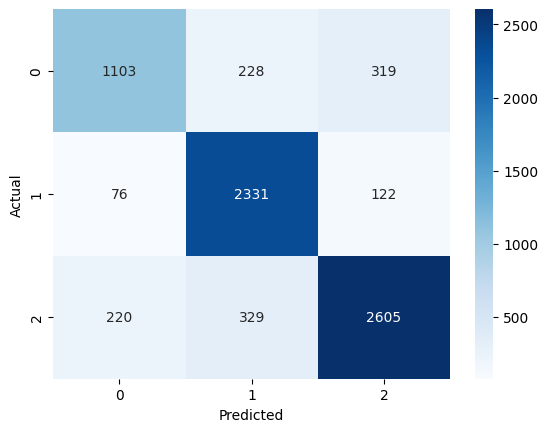

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Comparison

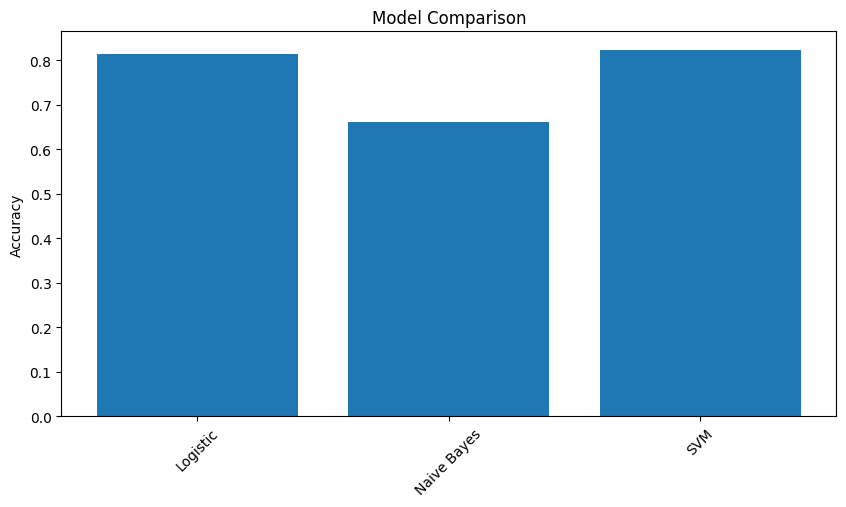

In [12]:
models = [
    "Logistic",
    "Naive Bayes",
    "SVM"

]

accuracy = [
    0.8138,
    0.6616,
    0.8235,
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(models, accuracy)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

# Table Comparison

In [13]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy
})

comparison

,Model,Accuracy
0,Logistic,0.8138
1,Naive Bayes,0.6616
2,SVM,0.8235


In [ ]:
import pickle

pickle.dump(model, open("svmmodel.pkl", "wb"))
pickle.dump(tfidf, open("tfidfvectorizer.pkl", "wb"))